In [1]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image


In [7]:
from pathlib import Path

DATASET_ROOT = Path("../datasets/raw/archive")

print("Exists:", DATASET_ROOT.exists())
print("Is directory:", DATASET_ROOT.is_dir())
print("Resolved path:", DATASET_ROOT.resolve())

Exists: True
Is directory: True
Resolved path: C:\Users\Sagar N\Downloads\5 sem\MedVision\MedVision\datasets\raw\archive


In [9]:
for split in DATASET_ROOT.iterdir():
    if not split.is_dir():
        continue

    print(split.name)

    for cls in split.iterdir():
        if cls.is_dir():
            print("   ", cls.name)

test
    normal
    pneumonia
    tuberculosis
train
    normal
    pneumonia
    tuberculosis
val
    normal
    pneumonia
    tuberculosis


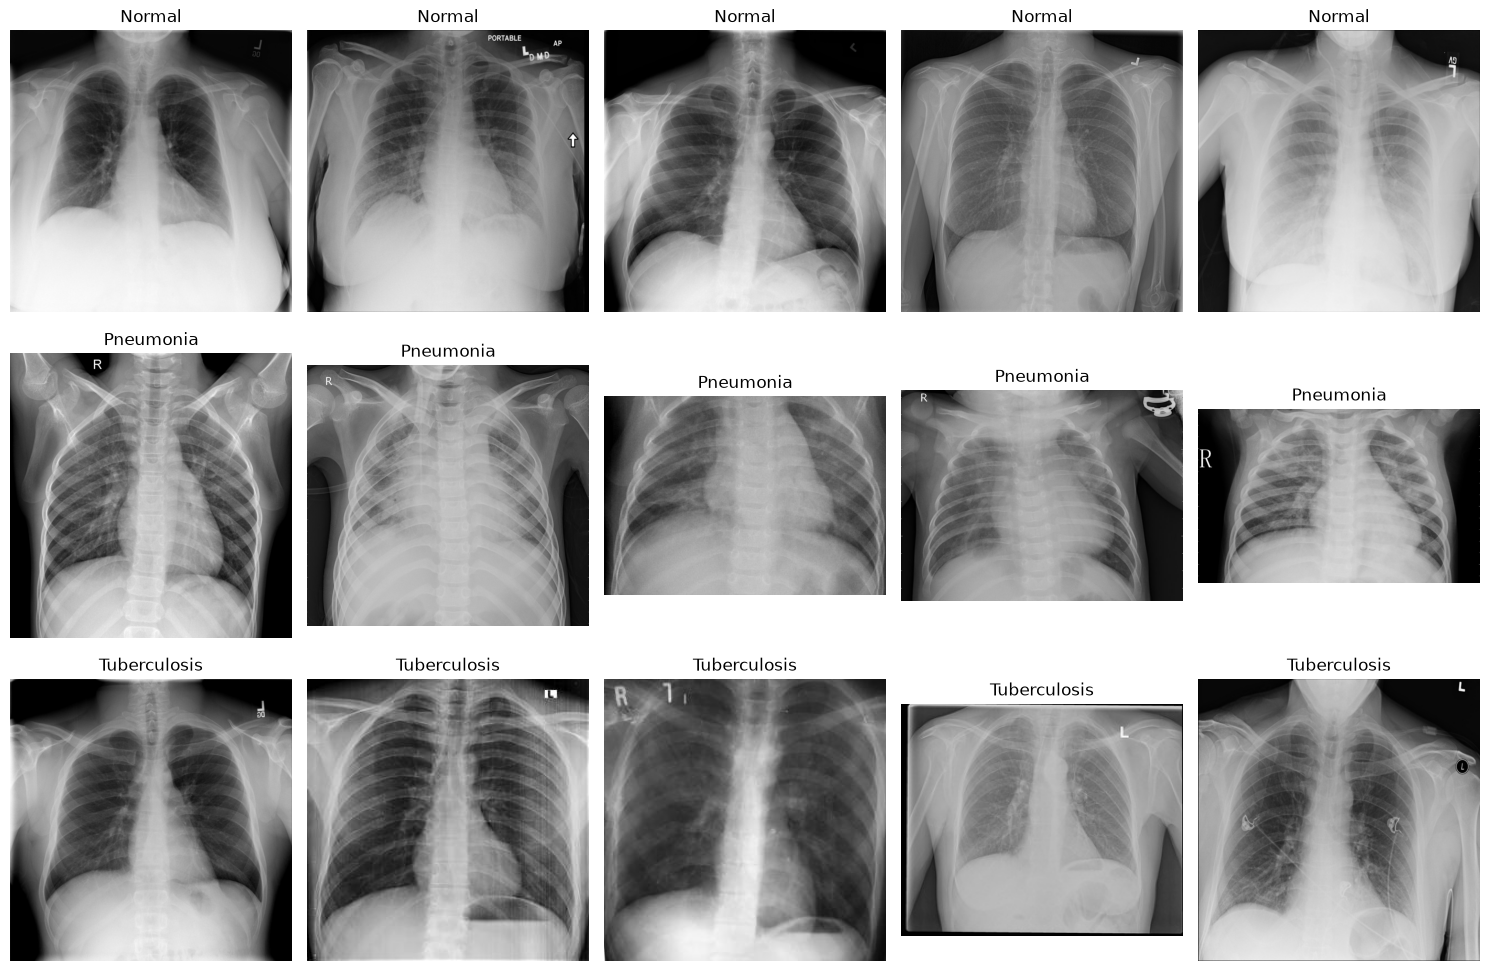

In [11]:
train_path = DATASET_ROOT / "train"

classes = sorted(
    [folder for folder in train_path.iterdir() if folder.is_dir()]
)

fig, axes = plt.subplots(3, 5, figsize=(15, 10))

for row, class_folder in enumerate(classes):

    images = list(class_folder.glob("*.jpg"))

    samples = random.sample(images, 5)

    for col, image_path in enumerate(samples):

        image = Image.open(image_path)

        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].set_title(class_folder.name.capitalize())
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [13]:
sizes = []

for image_path in train_path.rglob("*.jpg"):

    image = Image.open(image_path)

    sizes.append(image.size)

print(set(sizes))


{(976, 544), (1994, 1839), (848, 624), (1762, 1224), (1454, 1071), (880, 576), (1794, 1176), (1496, 1333), (1318, 1067), (1630, 1333), (1592, 1041), (1778, 1168), (1856, 1496), (1016, 616), (2434, 2376), (1322, 1037), (1328, 968), (1854, 1572), (1400, 1136), (1562, 1284), (920, 648), (1408, 960), (1712, 1488), (1786, 1437), (872, 608), (1846, 1488), (1624, 1375), (2746, 2382), (1440, 800), (1232, 1000), (1360, 920), (796, 469), (1136, 654), (1857, 1317), (888, 552), (1754, 1341), (2022, 1384), (840, 512), (243, 256), (1720, 1348), (792, 584), (1360, 776), (256, 195), (1542, 1341), (2096, 1864), (1256, 984), (928, 624), (1850, 1314), (1616, 1147), (2474, 2224), (1742, 1372), (812, 678), (1312, 1144), (1654, 1259), (2000, 1896), (1272, 928), (1224, 888), (1504, 1171), (1890, 1615), (816, 568), (1736, 1328), (1256, 840), (928, 480), (2280, 2066), (1803, 1238), (1312, 1000), (832, 512), (1300, 617), (1806, 1392), (1400, 704), (255, 208), (1902, 1854), (1224, 744), (1216, 1032), (1844, 1504

In [15]:
from collections import Counter

sizes = []

for image_path in train_path.rglob("*.jpg"):
    image = Image.open(image_path)
    sizes.append(image.size)

size_counts = Counter(sizes)

print(f"Number of unique resolutions: {len(size_counts)}\n")

print("Top 10 most common resolutions:\n")

for size, count in size_counts.most_common(10):
    print(f"{size} : {count}")

Number of unique resolutions: 4371

Top 10 most common resolutions:

(512, 512) : 6140
(256, 256) : 3280
(1024, 1024) : 2920
(256, 211) : 716
(211, 256) : 244
(256, 192) : 91
(256, 246) : 78
(256, 191) : 49
(1760, 2140) : 21
(256, 204) : 21
